# Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('clean_sales.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product Name,Sales,Quantity,Discount,Profit,Shipping_Days,Profit_Margin,Year,Month,Year_Month
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,4,0.3375,2023,1,2023-01
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,4,-1.5500,2023,1,2023-01
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Avery 508,11.784,3,0.2,4.2717,4,0.3625,2023,1,2023-01
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,4,-0.2375,2023,1,2023-01
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,7,0.2500,2023,1,2023-01


## 2. Chart 1: Sub-Category Profitability

### 2.1 Purpose
Identify which product lines make money and which lose money.

### 2.2 Data Source
- SQL Query: `02_profitability.sql`
- Cleaned Dataset: `clean_sales.csv`

### 2.3 Key Questions
- Which sub-categories have the highest profit margins?
- Which sub-categories are losing money?
- What is the overall margin distribution across product lines?

### 2.4 Methodology
- Group data by `Sub-Category`
- Calculate true margin: `SUM(Profit) / SUM(Sales)`
- Sort from lowest to highest margin
- Color-code: green for profit, red for loss
- Add zero reference line for break-even visibility

### 2.5 Chart

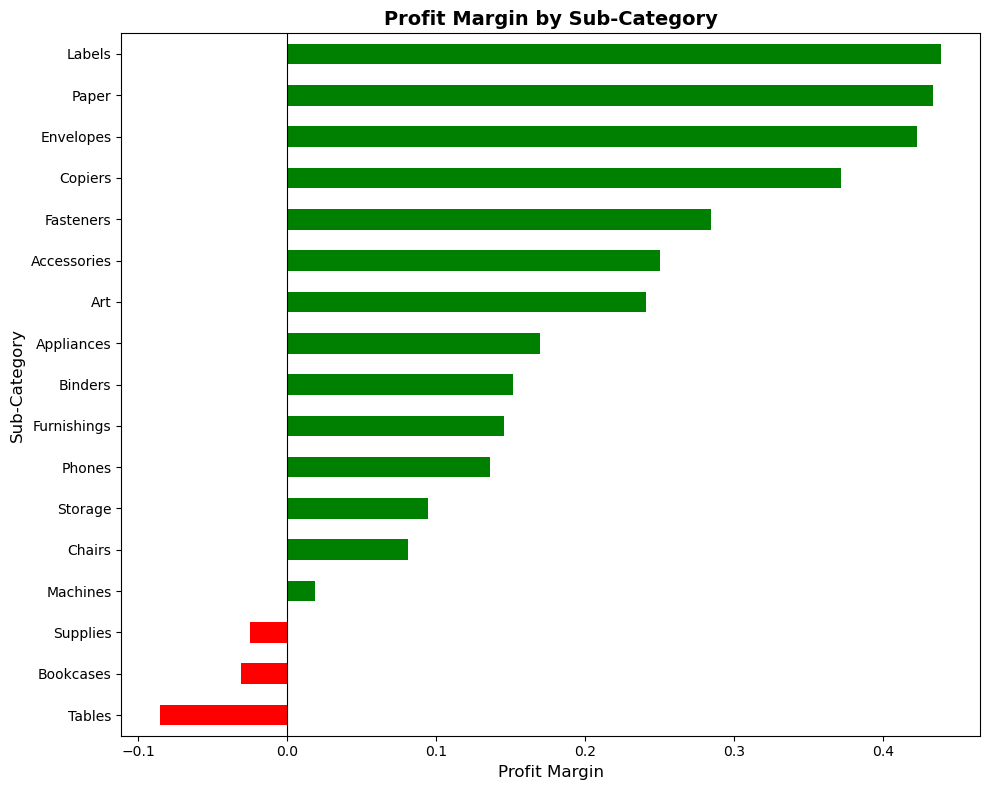

In [17]:
# Calculate profit margin by Sub-Category
subcat = df.groupby('Sub-Category')['Profit'].sum() / df.groupby('Sub-Category')['Sales'].sum()

# Sort from lowest to highest margin
subcat = subcat.sort_values()

# Color: red for loss, green for profit
colors = ['red' if x < 0 else 'green' for x in subcat.values]

# Create figure
plt.figure(figsize=(10, 8))

# Plot horizontal bar chart
subcat.plot(kind='barh', color=colors)

# Add zero reference line
plt.axvline(x=0, color='black', linewidth=0.8)

# Labels and title
plt.title('Profit Margin by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Profit Margin', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)

# Prevent label cutoff
plt.tight_layout()

# Save to your specific folder using absolute path
plt.savefig(r'D:\Computer Science\Data Science\Data Analysis\Projects\Superstore\retail-sales-analysis\outputs\figures\profit_margin_by_subcategory.png', 
            dpi=300, bbox_inches='tight')

# Display
plt.show()


### 2.6 Key Takeaways
- **Top performers:** Labels (43.9%), Paper (43.4%), Envelopes (42.3%) — all Office Supplies consumables
- **Major loss leaders:** Tables (−8.5%), Bookcases (−3.1%), Supplies (−2.5%) — Furniture category
- **Same products, different outcomes:** Technology (Copiers 37% vs Machines 1.8%) shows pricing strategy matters more than product type

## 3. Chart 2: Discount Impact Analysis

### 3.1 Purpose
Measure how different discount levels affect profitability.

### 3.2 Data Source
- SQL Query: `03_discount_impact.sql`
- Cleaned Dataset: `clean_sales.csv`

### 3.3 Key Questions
- What is the profit margin for each discount tier?
- At what discount level does profitability turn negative?
- How many orders fall into each discount category?

### 3.4 Methodology
- Create discount tiers: No Discount, Low (1-20%), Medium (21-50%), High (&gt;50%)
- Group orders by tier
- Calculate true margin: `SUM(Profit) / SUM(Sales)` per tier
- Sort in logical order: No Discount → High
- Color-code: green for positive margin, red for negative
- Add zero reference line for break-even visibility

### 3.5 Chart

C:\Users\aziza\AppData\Local\Temp\ipykernel_2012\2208456359.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tier = df.groupby('Discount_Tier').apply(lambda x: x['Profit'].sum() / x['Sales'].sum())


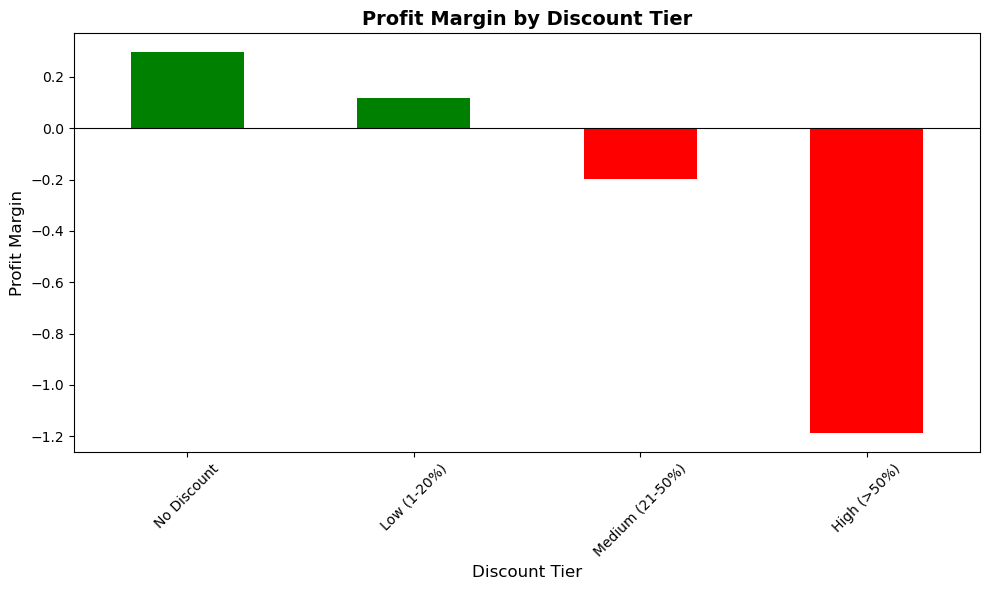

In [23]:
# Create discount tier function
def discount_tier(discount):
    if discount == 0:
        return 'No Discount'
    elif discount <= 0.2:
        return 'Low (1-20%)'
    elif discount <= 0.5:
        return 'Medium (21-50%)'
    else:
        return 'High (>50%)'

# Apply to dataframe
df['Discount_Tier'] = df['Discount'].apply(discount_tier)

# Group by tier and calculate margin
tier = df.groupby('Discount_Tier').apply(lambda x: x['Profit'].sum() / x['Sales'].sum())

# Sort in logical order
tier = tier.reindex(['No Discount', 'Low (1-20%)', 'Medium (21-50%)', 'High (>50%)'])

# Create figure
plt.figure(figsize=(10, 6))

# Plot vertical bar chart
colors = ['green' if x > 0 else 'red' for x in tier]
tier.plot(kind='bar', color=colors)

# Add horizontal line at zero
plt.axhline(y=0, color='black', linewidth=0.8)

# Labels and title
plt.title('Profit Margin by Discount Tier', fontsize=14, fontweight='bold')
plt.xlabel('Discount Tier', fontsize=12)
plt.ylabel('Profit Margin', fontsize=12)

# Rotate x labels for readability
plt.xticks(rotation=45)

# Prevent label cutoff
plt.tight_layout()

# Save figure
plt.savefig(r'D:\Computer Science\Data Science\Data Analysis\Projects\Superstore\retail-sales-analysis\outputs\figures\discount_impact.png', 
            dpi=300, bbox_inches='tight')

# Display
plt.show()



### 3.6 Key Takeaways
- **No Discount = 29.6% margin** — best performance, 4,925 orders (48% of business)
- **Low Discount (1-20%) = 12.7% margin** — acceptable, only 148 orders
- **Medium Discount (21-50%) = 3.0% margin** — dangerous, 4,247 orders (42% of business)
- **High Discount (&gt;50%) = −118.7% margin** — catastrophic, 874 orders actively lose money
- **Critical insight:** 42% of orders use medium-to-high discounts and barely break even or lose money

## 4. Chart 3: Monthly Sales and Profit Trends

### 4.1 Purpose
Track business performance over time to identify seasonal patterns and growth trends.

### 4.2 Data Source
- SQL Query: `05_time_trends.sql`
- Cleaned Dataset: `clean_sales.csv`

### 4.3 Key Questions
- Are sales growing or shrinking month by month?
- Is profit keeping pace with sales?
- Are there seasonal patterns (busy months vs slow months)?
- How fast are we shipping orders on average?

### 4.4 Methodology
- Group data by `Year_Month`
- Aggregate: sum `Sales`, sum `Profit`
- Plot dual line chart: Sales (blue) and Profit (green)
- Add zero reference line to identify loss months
- Show every 3rd month on x-axis to prevent label crowding
- Add grid for easier value estimation

### 4.5 Chart

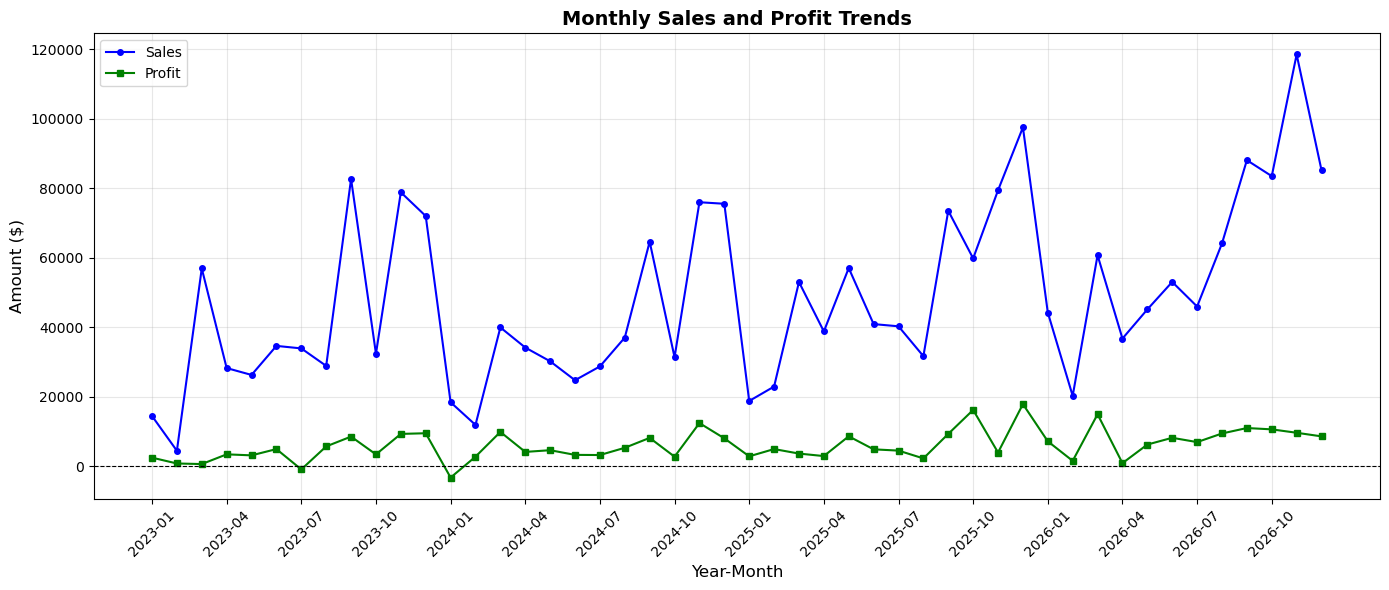

In [27]:
# Group by month
monthly = df.groupby('Year_Month').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()
# Group by Year_Month and sum Sales and Profit
monthly = df.groupby('Year_Month').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

# Create figure with wide size for time series
plt.figure(figsize=(14, 6))

# Plot Sales line
plt.plot(monthly['Year_Month'], monthly['Sales'], 
         label='Sales', color='blue', marker='o', markersize=4)

# Plot Profit line
plt.plot(monthly['Year_Month'], monthly['Profit'], 
         label='Profit', color='green', marker='s', markersize=4)

# Add horizontal line at zero for reference
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

# Title and labels
plt.title('Monthly Sales and Profit Trends', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)

# Rotate x-axis labels to prevent overlap
# Show every 3rd month to reduce crowding
plt.xticks(monthly['Year_Month'][::3], rotation=45)

# Add legend to identify lines
plt.legend()

# Add grid for easier reading
plt.grid(True, alpha=0.3)

# Prevent label cutoff
plt.tight_layout()

# Save figure
plt.savefig(r'D:\Computer Science\Data Science\Data Analysis\Projects\Superstore\retail-sales-analysis\outputs\figures\monthly_trends.png', 
            dpi=300, bbox_inches='tight')

# Display
plt.show()


### 4.6 Key Takeaways
- **Strong Q4 seasonality:** November and December are consistently peak months ($72K-$118K)
- **Weak Q1:** February is dead every year ($4K-$22K), January sometimes unprofitable
- **Growth trend:** 2026 outperformed all previous years, especially October ($118K)
- **Profit volatility:** January 2024 lost $3,190 despite $18K sales — post-holiday discounting
- **Shipping stable:** 3-4 days average, no seasonal variation

## 5. Chart 4: Sales vs Profit Scatter Plot

### 5.1 Purpose
Diagnose the relationship between sales revenue and profit, revealing which orders make or lose money.

### 5.2 Data Source
- Cleaned Dataset: `clean_sales.csv`
- Engineered columns: `Discount`, `Category`

### 5.3 Key Questions
- Do higher sales always mean higher profit?
- Which product categories cluster in the profit vs loss zones?
- What role does discounting play in profitability?
- Where is the break-even threshold?

### 5.4 Methodology
- Plot each order as a dot: Sales (x-axis) vs Profit (y-axis)
- Color by Category: Technology, Furniture, Office Supplies
- Size by Discount: bigger dots = higher discount
- Add horizontal line at y=0 (break-even line)
- Add vertical line at x=0 (reference)
- Use transparency (alpha=0.6) to reveal overlapping points
- Move legend outside plot to prevent overlap

### 5.5 Chart

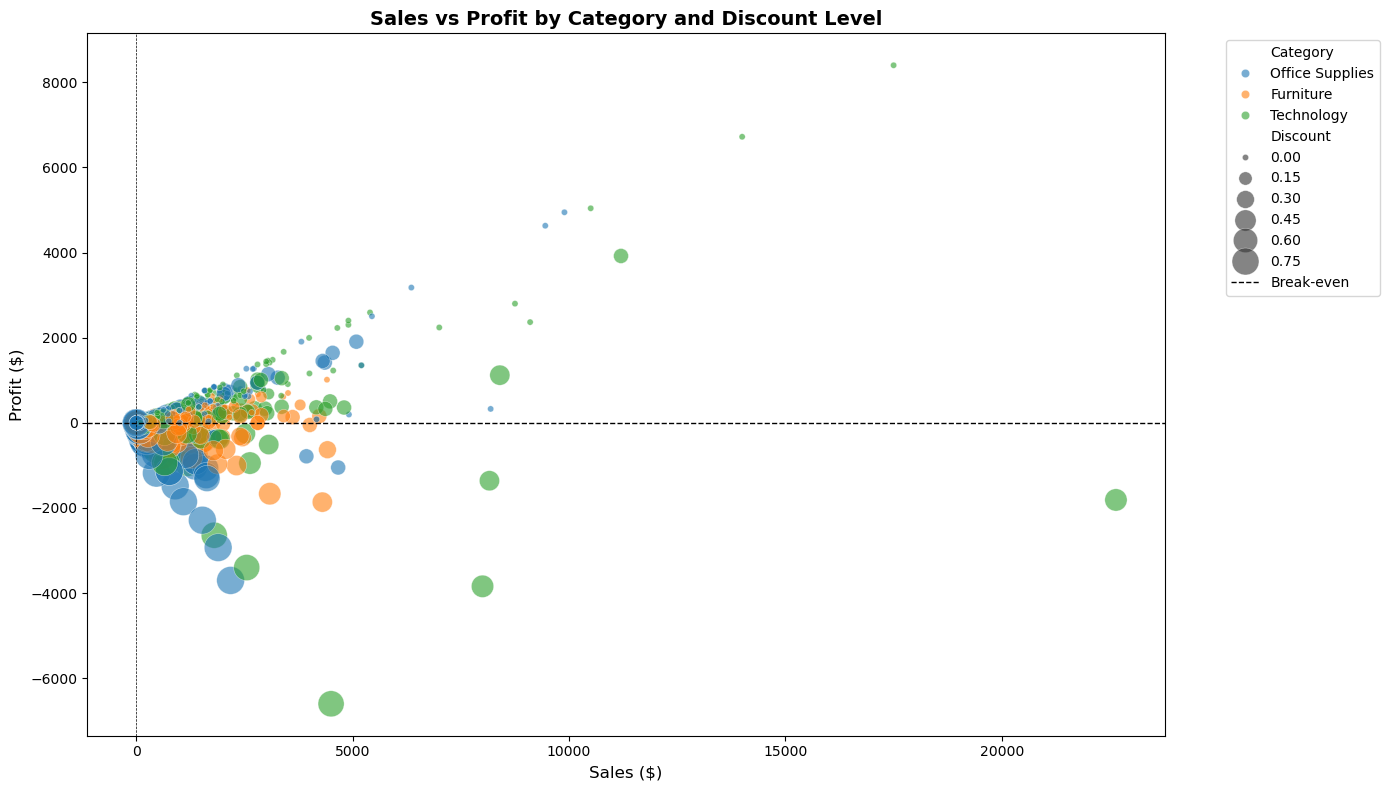

In [29]:
# Create figure
plt.figure(figsize=(14, 8))

# Create scatter plot using seaborn for better color handling
# hue = Category (color by product category)
# size = Discount (bigger dots = bigger discount)
sns.scatterplot(data=df, 
                x='Sales', 
                y='Profit', 
                hue='Category',           # Color by category
                size='Discount',          # Size by discount amount
                sizes=(20, 400),          # Min and max dot size
                alpha=0.6)              # Transparency to see overlap

# Add horizontal line at zero profit (break-even line)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Break-even')

# Add vertical line at zero sales (reference)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)

# Title and labels
plt.title('Sales vs Profit by Category and Discount Level', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)

# Move legend outside plot to prevent overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Prevent label cutoff
plt.tight_layout()

# Save figure
plt.savefig(r'D:\Computer Science\Data Science\Data Analysis\Projects\Superstore\retail-sales-analysis\outputs\figures\sales_vs_profit_scatter.png', 
            dpi=300, bbox_inches='tight')

# Display
plt.show()



### 5.6 Key Takeaways
- **High sales ≠ high profit:** Many large dots (high discount) fall below zero line
- **Office Supplies:** Most dots below zero — heavily discounted, especially Binders and Storage
- **Technology:** Stays mostly above zero — sells at low/no discount, especially Copiers
- **Furniture:** Mixed — Tables and Bookcases lose money, Chairs break even
- **Discount is the killer:** Big dots cluster below zero line; small dots cluster above
- **Same product, two stories:** A $4,500 3D printer at 70% discount loses $6,600; 
  a $17,500 copier at 0% discount makes $8,400

## 6. Chart 5: Top 10 Customers by Profit

### 6.1 Purpose
Identify the most valuable customers and analyze which segment drives the most profit.

### 6.2 Data Source
- SQL Query: `04_customer_analysis.sql`
- Cleaned Dataset: `clean_sales.csv`

### 6.3 Key Questions
- Who are the top 10 customers by total profit?
- Which customer segment (Corporate, Consumer, Home Office) dominates?
- What is the profit margin for top customers?
- How many orders do top customers place?

### 6.4 Methodology
- Group by `Customer ID`, `Customer Name`, `Segment`
- Sum `Profit` for each customer
- Sort descending and select top 10
- Plot horizontal bar chart: Customer Name (y-axis) vs Profit (x-axis)
- Color by Segment: Corporate, Consumer, Home Office
- Use Seaborn for automatic color palette and legend

### 6.5 Chart

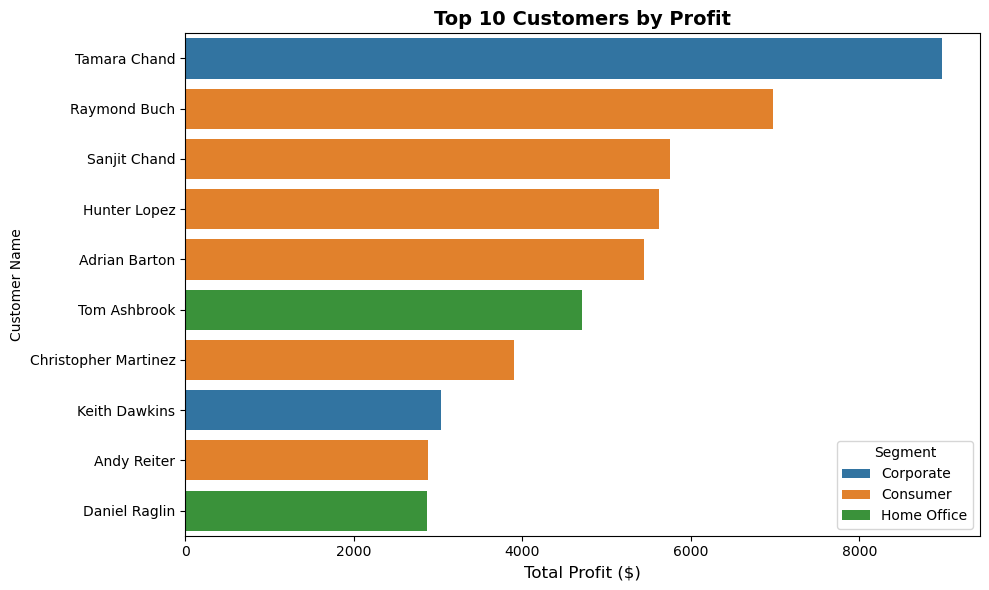

In [39]:
# Step 1: Group by customer (list inside groupby!)
customers = df.groupby(['Customer ID', 'Customer Name', 'Segment']).agg({
    'Profit': 'sum'
}).reset_index()

# Step 2: Top 10 by profit
top10 = customers.nlargest(10, 'Profit')

# Step 3: Plot horizontal bar
plt.figure(figsize=(10, 6))
sns.barplot(data=top10, y='Customer Name', x='Profit', hue='Segment')

# Step 4: Polish
plt.title('Top 10 Customers by Profit', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)', fontsize=12)
plt.tight_layout()

# Save
plt.savefig(r'D:\Computer Science\Data Science\Data Analysis\Projects\Superstore\retail-sales-analysis\outputs\figures\top_customers.png', 
          dpi=300, bbox_inches='tight')

plt.show()

### 6.6 Key Takeaways
- **Corporate dominates:** 5-6 of top 10 customers are Corporate segment
- **Best customer:** Tamara Chand (Corporate) — $8,981 profit at 47% margin
- **Top 10 margins:** Mostly 30-47%, well above company average of 12.6%
- **Volume ≠ Profit:** Sanjit Chand has most orders (9) but not highest profit
- **Consumer presence:** 3-4 in top 10, solid but smaller individual contributions
- **Home Office:** 1-2 in top 10, occasional large equipment purchases